<a href="https://colab.research.google.com/github/mw2304/SummerProject2026/blob/main/combined_cnn_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Models for Annihilation Position Reconstruction

This notebook combines two separate convolutional neural network (CNN) pipelines that were originally developed in two different notebooks:

- **Part A — Deterministic CNN** (from `CNNModel3GAMMA.ipynb`): a CNN + plane-feature model that directly regresses the annihilation position `(X, Y, Z)`.
- **Part B — Probabilistic CNN** (from `probablisticCNN.ipynb`): the same style of CNN, but trained with a Gaussian negative-log-likelihood loss so it predicts a mean position **and** a per-axis uncertainty, plus a physics-informed projection of the prediction onto the detector-hit plane.

The two models are kept fully separate (separate data loading, separate architectures, separate training runs) so you can see how each one works on its own. **Part C** then brings the results of both together for a side-by-side comparison.

> **Notes on this tidy-up**
> - Duplicate/dead cells, unused variables, and a couple of bugs in the original notebooks have been cleaned up (see the "What changed" note at the end of each part).
> - The `accuracy` metric has been removed everywhere — this is a continuous regression problem (predicting X/Y/Z in mm), so classification accuracy is not a meaningful metric here.
> - This environment doesn't have TensorFlow, `uproot`, or the underlying ROOT files (`new3merged.root`, `augmerged.root`), so the code below has **not** been executed here — run it top-to-bottom in your own environment.
> - Part A and Part B load data from **different** ROOT files. They're still compared side-by-side in Part C, but bear that caveat in mind — it isn't a strictly controlled head-to-head unless both are pointed at the same dataset.


## 0. Shared setup

Both models use the same libraries and the same event → image conversion logic, so that shared code lives here once instead of being duplicated in each part.

In [6]:
%pip install uproot
%pip install awkward_pandas

In [7]:
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [8]:
def load_three_gamma_events(root_file, tree_name="ThreeG_NCS"):
    """Open a ROOT file and pull out the branches needed for the three-gamma
    (NCS) events used by both models."""

    branches = [
        "RunID",
        "EventID",
        "GammaIndex",
        "X_mm",
        "Y_mm",
        "Z_mm",
        "EnergyDeposit_keV",
        "PreEnergy_keV",
        "PostEnergy_keV",
        "AnnihilX_mm",
        "AnnihilY_mm",
        "AnnihilZ_mm",
    ]

    file = uproot.open(root_file)
    tree = file[tree_name]
    df = tree.arrays(branches, library="pd")

    return df


def get_axis_ranges(df):
    """Min/max extent of the detector hits, used to fix the histogram
    binning so every event image lines up on the same grid."""

    xmin, xmax = df.X_mm.min(), df.X_mm.max()
    ymin, ymax = df.Y_mm.min(), df.Y_mm.max()
    zmin, zmax = df.Z_mm.min(), df.Z_mm.max()

    return xmin, xmax, ymin, ymax, zmin, zmax


def build_images_targets_planes(df, xmin, xmax, ymin, ymax, zmin, zmax, img_size=64):
    """Turn each 3-gamma event into:

    - a (img_size, img_size, 3) "image" whose channels are the energy-weighted
      XY, XZ and YZ projections of the three detector hits
    - a regression target: the true annihilation position (X, Y, Z)
    - a plane feature [A, B, C, D] describing the plane through the three
      detector hits (Ax + By + Cz + D = 0), used as auxiliary input to the CNN

    Events that don't have exactly 3 hits, or whose hits are collinear
    (degenerate plane), are skipped.
    """

    images, targets, plane_features = [], [], []

    event_groups = df.groupby(["RunID", "EventID"], sort=False)
    print(f"Building images from {event_groups.ngroups} events...")

    for i, ((run_id, event_id), event) in enumerate(event_groups):

        points = event.sort_values("GammaIndex")[["X_mm", "Y_mm", "Z_mm"]].values
        if len(points) != 3:
            continue

        P1, P2, P3 = points

        # Plane through the three detector hits
        v1, v2 = P2 - P1, P3 - P1
        normal = np.cross(v1, v2)

        if np.linalg.norm(normal) == 0:
            continue

        normal = normal / np.linalg.norm(normal)
        A, B, C = normal
        D = -np.dot(normal, P1)
        plane_features.append([A, B, C, D])

        # Energy-weighted 2D projections as image channels
        image = np.zeros((img_size, img_size, 3), dtype=np.float32)

        H_xy, _, _ = np.histogram2d(
            event["X_mm"], event["Y_mm"],
            bins=img_size, range=[[xmin, xmax], [ymin, ymax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 0] = H_xy

        H_xz, _, _ = np.histogram2d(
            event["X_mm"], event["Z_mm"],
            bins=img_size, range=[[xmin, xmax], [zmin, zmax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 1] = H_xz

        H_yz, _, _ = np.histogram2d(
            event["Y_mm"], event["Z_mm"],
            bins=img_size, range=[[ymin, ymax], [zmin, zmax]],
            weights=event["EnergyDeposit_keV"],
        )
        image[:, :, 2] = H_yz

        images.append(image)
        targets.append([
            event["AnnihilX_mm"].iloc[0],
            event["AnnihilY_mm"].iloc[0],
            event["AnnihilZ_mm"].iloc[0],
        ])

        if (i + 1) % 1000 == 0:
            print(f"{i + 1} events processed")

    images = np.array(images, dtype=np.float16)
    targets = np.array(targets, dtype=np.float32)
    plane_features = np.array(plane_features, dtype=np.float32)

    print()
    print("Images shape :", images.shape)
    print("Targets shape:", targets.shape)
    print("Plane features shape:", plane_features.shape)

    return images, targets, plane_features


def build_cnn_backbone(image_input):
    """Three conv+pool blocks shared by both models, turning the detector
    image into a flat feature vector."""

    x = Conv2D(16, (3, 3), activation="relu")(image_input)
    x = MaxPooling2D()(x)

    x = Conv2D(32, (3, 3), activation="relu")(x)
    x = MaxPooling2D()(x)

    x = Conv2D(64, (3, 3), activation="relu")(x)
    x = MaxPooling2D()(x)

    return Flatten()(x)


def build_plane_branch(plane_input, units=16):
    """Small dense branch that embeds the plane-equation features so they
    can be concatenated with the CNN's image features."""

    return Dense(units, activation="relu")(plane_input)

---
## Part A — Deterministic CNN (direct X, Y, Z regression)

This model takes the detector image and the plane features and directly regresses the annihilation position. It's trained with plain MSE loss and benchmarked against a naive baseline (always predicting the mean training position).

### A.1 Load data

In [9]:
ROOT_FILE_A = "augmerged.root"

df_A = load_three_gamma_events(ROOT_FILE_A)

print(df_A.head())

event_sizes_A = df_A.groupby(["RunID", "EventID"]).size()
print(event_sizes_A.value_counts())
print("Number of detector hits:", len(df_A))
print("Number of events       :", df_A[["RunID", "EventID"]].drop_duplicates().shape[0])
print()
print(df_A.describe())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_36283167_1       43           0  22.533781  45.725643  -6.039716   
1  slurm_36283167_1       43           1 -19.154974 -41.295967  42.954437   
2  slurm_36283167_1       43           2  10.009033  22.802109 -44.240387   
3  slurm_36283167_1       56           0  15.187184  14.526692  46.622974   
4  slurm_36283167_1       56           1   1.183054 -10.753192 -51.622868   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         187.380234     187.380234             0.0     3.079860     6.565360   
1         471.598907     471.598907             0.0     3.079860     6.565360   
2         363.018677     363.018677             0.0     3.079860     6.565360   
3         492.708618     492.708618             0.0    -0.369778     0.324251   
4         304.623718     304.623718             0.0    -0.369778     0.324251   

   AnnihilZ_mm  
0    -6.969770  
1    -6.969770  

### A.2 Build detector images and regression targets

In [10]:
IMG_SIZE = 64

xmin_A, xmax_A, ymin_A, ymax_A, zmin_A, zmax_A = get_axis_ranges(df_A)
print(xmin_A, xmax_A)
print(ymin_A, ymax_A)
print(zmin_A, zmax_A)

images_A, targets_A, plane_features_A = build_images_targets_planes(
    df_A, xmin_A, xmax_A, ymin_A, ymax_A, zmin_A, zmax_A, img_size=IMG_SIZE
)

-99.15685272216797 95.1434555053711
-92.13552856445312 96.26758575439453
-95.55072784423828 98.47635650634766
Building images from 18591 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed

Images shape : (18591, 64, 64, 3)
Targets shape: (18591, 3)
Plane features shape: (18591, 4)


In [11]:
# Normalise images to [0, 1]
images_A = images_A / np.max(images_A)

print(images_A.min(), images_A.max())

0.0 1.0


### A.3 Train / test split

In [12]:
x_train_A, x_test_A, plane_train_A, plane_test_A, y_train_A, y_test_A = train_test_split(
    images_A,
    plane_features_A,
    targets_A,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print("Training images :", x_train_A.shape)
print("Training planes :", plane_train_A.shape)
print("Training targets:", y_train_A.shape)
print("Test images     :", x_test_A.shape)
print("Test planes     :", plane_test_A.shape)
print("Test targets    :", y_test_A.shape)

Training images : (14872, 64, 64, 3)
Training planes : (14872, 4)
Training targets: (14872, 3)
Test images     : (3719, 64, 64, 3)
Test planes     : (3719, 4)
Test targets    : (3719, 3)


### A.4 Scale targets

In [13]:
target_scaler_A = StandardScaler()

y_train_scaled_A = target_scaler_A.fit_transform(y_train_A)
y_test_scaled_A = target_scaler_A.transform(y_test_A)

print(y_train_scaled_A[0])

[ 0.920658  -0.8802103 -1.9163066]


### A.5 Build the model

In [14]:
image_input_A = Input(shape=(64, 64, 3), name="image_input")
x_A = build_cnn_backbone(image_input_A)

plane_input_A = Input(shape=(4,), name="plane_input")
plane_branch_A = build_plane_branch(plane_input_A)

combined_A = Concatenate()([x_A, plane_branch_A])
combined_A = Dense(128, activation="relu")(combined_A)
combined_A = Dropout(0.3)(combined_A)

# Deterministic regression output: (x, y, z)
output_A = Dense(3, name="xyz")(combined_A)

model_A = Model(inputs=[image_input_A, plane_input_A], outputs=output_A)
model_A.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 62, 62,    │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 6, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_input         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2304)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         80 │ plane_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2320)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    297,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xyz (Dense)         │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,139 (1.23 MB)

 Trainable params: 321,139 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### A.6 Compile & train

In [15]:
model_A.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

early_stop_A = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

history_A = model_A.fit(
    [x_train_A, plane_train_A],
    y_train_scaled_A,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    callbacks=[early_stop_A],
)

Epoch 1/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.8678 - mae: 0.7690 - val_loss: 0.7489 - val_mae: 0.7060
Epoch 2/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.7139 - mae: 0.6832 - val_loss: 0.6678 - val_mae: 0.6563
Epoch 3/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.6565 - mae: 0.6516 - val_loss: 0.6203 - val_mae: 0.6317
Epoch 4/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.6257 - mae: 0.6331 - val_loss: 0.6266 - val_mae: 0.6353
Epoch 5/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.5967 - mae: 0.6174 - val_loss: 0.5892 - val_mae: 0.6111
Epoch 6/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5739 - mae: 0.6049 - val_loss: 0.5806 - val_mae: 0.6078
Epoch 7/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.5539 - mae: 0.5932 - val_loss: 0.6000 - val_mae: 0.6166
Epoch 8/40
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.5390 - mae: 0.5844 - val_loss: 0.5780 - val_mae: 0.6027
Epoch 9/40
1488/1488 ━━━━━━━━━━━━━━━━

### A.7 Training curves

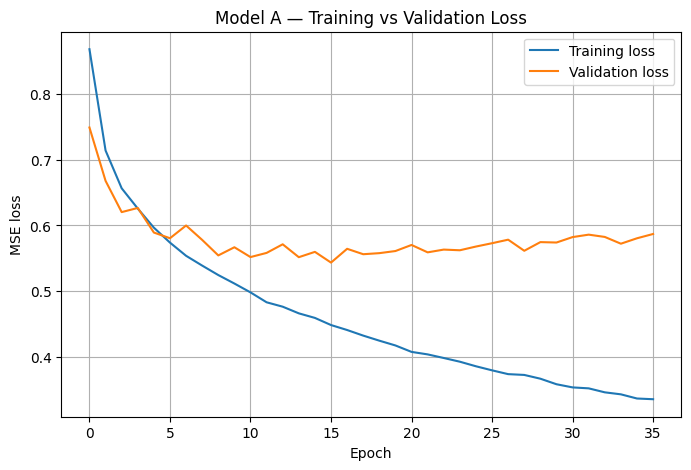

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_A.history["loss"], label="Training loss")
plt.plot(history_A.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Model A — Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

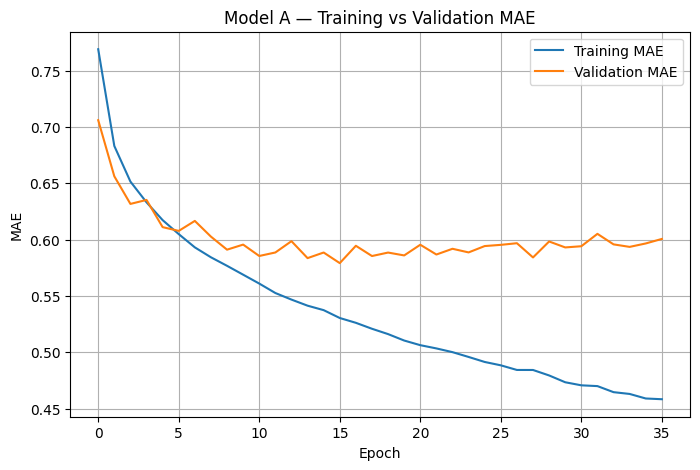

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history_A.history["mae"], label="Training MAE")
plt.plot(history_A.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Model A — Training vs Validation MAE")
plt.legend()
plt.grid()
plt.show()

### A.8 Predictions vs. a naive baseline

In [18]:
prediction_scaled_A = model_A.predict([x_test_A, plane_test_A])
prediction_A = target_scaler_A.inverse_transform(prediction_scaled_A)

for i in range(5):
    print("True:     ", y_test_A[i])
    print("Predicted:", prediction_A[i])
    print()

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
True:      [  5.387624    -0.08580948 -10.092469  ]
Predicted: [ 4.4716396  2.9978921 -9.336331 ]

True:      [ 4.315522   1.6260263 -7.961517 ]
Predicted: [ 2.131946   2.0572188 -9.130814 ]

True:      [ 3.8994508  3.005647  -8.104934 ]
Predicted: [ 2.4586587  3.31136   -7.152089 ]

True:      [ 2.7971644  6.0933194 -7.1500335]
Predicted: [ 0.9345133  2.8776603 -7.694203 ]

True:      [ 1.5251509   0.22125395 -8.647183  ]
Predicted: [ 1.5111843  1.4593443 -9.011517 ]



In [19]:
position_error_A = prediction_A - y_test_A

distance_error_A = np.sqrt(np.sum(position_error_A ** 2, axis=1))

print("Mean annihilation position error:", np.mean(distance_error_A), "mm")
print("Median annihilation position error:", np.median(distance_error_A), "mm")

Mean annihilation position error: 2.5021005 mm
Median annihilation position error: 2.3381288 mm


In [20]:
# Naive baseline: always predict the mean training position
mean_position_A = np.mean(y_train_A, axis=0)
baseline_prediction_A = np.tile(mean_position_A, (len(y_test_A), 1))

baseline_mse_A = mean_squared_error(y_test_A, baseline_prediction_A)
cnn_mse_A = mean_squared_error(y_test_A, prediction_A)

baseline_mae_A = mean_absolute_error(y_test_A, baseline_prediction_A)
cnn_mae_A = mean_absolute_error(y_test_A, prediction_A)

print("Baseline MSE:", baseline_mse_A, " | CNN MSE:", cnn_mse_A)
print("Baseline MAE:", baseline_mae_A, " | CNN MAE:", cnn_mae_A)

print("\nPer-axis MAE (baseline vs CNN):")
for i, coord in enumerate(["X", "Y", "Z"]):
    baseline_i = mean_absolute_error(y_test_A[:, i], baseline_prediction_A[:, i])
    cnn_i = mean_absolute_error(y_test_A[:, i], prediction_A[:, i])
    print(f"  {coord}: baseline={baseline_i:.2f} mm, CNN={cnn_i:.2f} mm")

r2_overall_A = r2_score(y_test_A, prediction_A)
r2_axes_A = [r2_score(y_test_A[:, i], prediction_A[:, i]) for i in range(3)]

print("\nOverall R2:", r2_overall_A)
print("Per-axis R2 (X, Y, Z):", r2_axes_A)

Baseline MSE: 4.758697032928467  | CNN MSE: 2.546839714050293
Baseline MAE: 1.818593144416809  | CNN MAE: 1.2507377862930298

Per-axis MAE (baseline vs CNN):
  X: baseline=1.68 mm, CNN=1.23 mm
  Y: baseline=2.27 mm, CNN=1.47 mm
  Z: baseline=1.51 mm, CNN=1.06 mm

Overall R2: 0.4563628137111664
Per-axis R2 (X, Y, Z): [0.384710431098938, 0.5017770528793335, 0.4826003313064575]


### A.9 Reconstruction, distributions and residuals

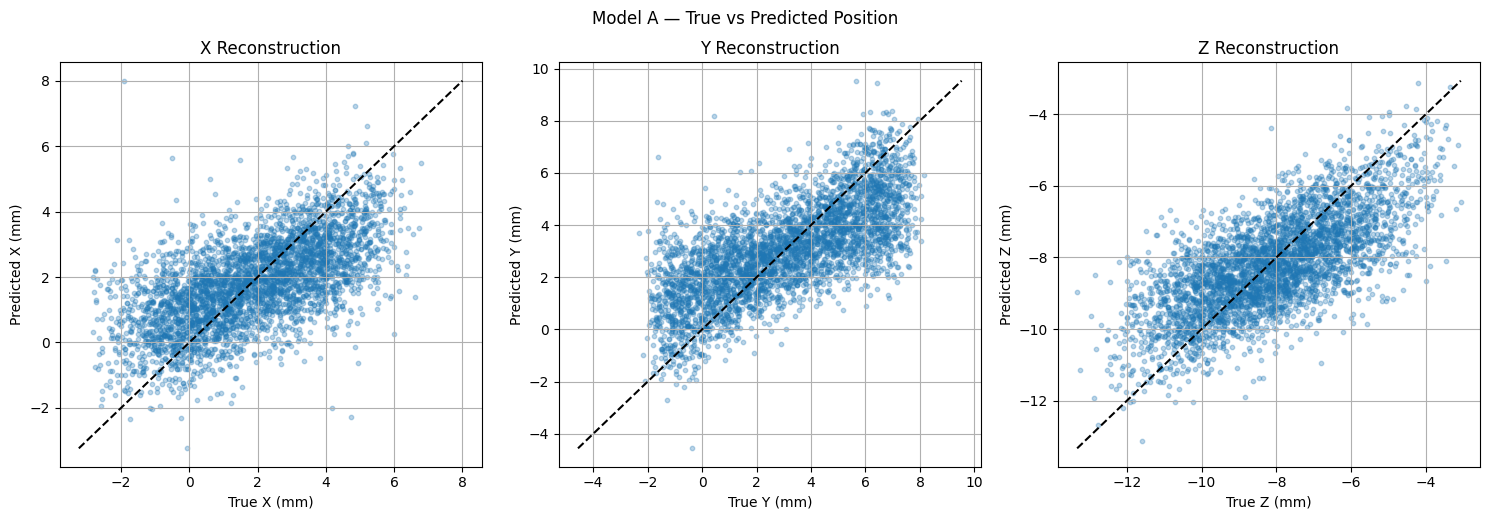

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):
    ax.scatter(y_test_A[:, i], prediction_A[:, i], alpha=0.3, s=10)
    lo = min(y_test_A[:, i].min(), prediction_A[:, i].min())
    hi = max(y_test_A[:, i].max(), prediction_A[:, i].max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"Predicted {coords[i]} (mm)")
    ax.set_title(f"{coords[i]} Reconstruction")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Model A — True vs Predicted Position", y=1.03)
plt.show()

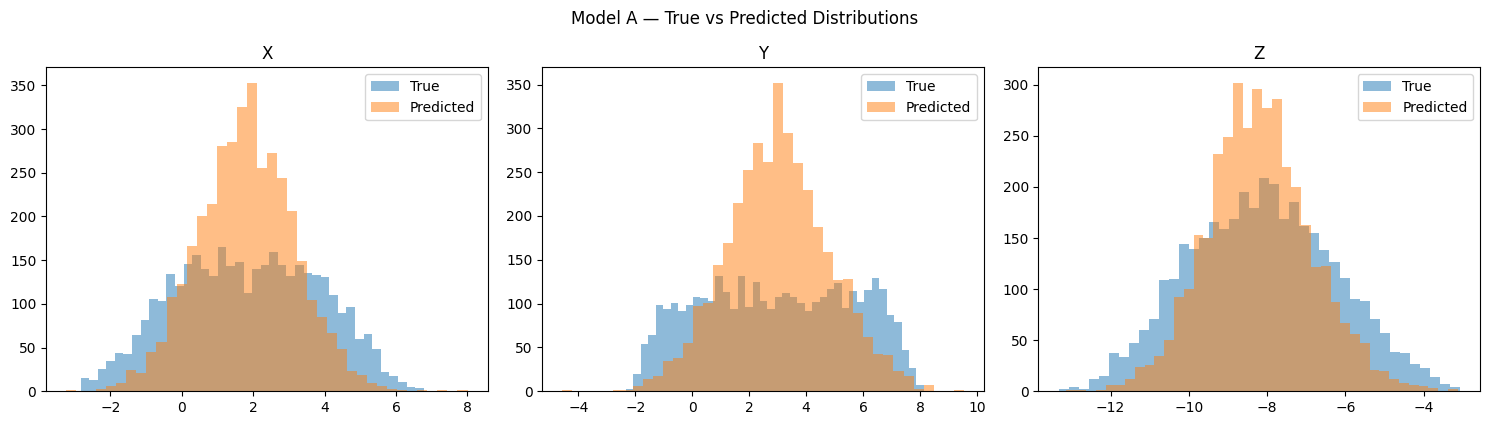

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):
    ax.hist(y_test_A[:, i], bins=40, alpha=0.5, label="True")
    ax.hist(prediction_A[:, i], bins=40, alpha=0.5, label="Predicted")
    ax.set_title(coords[i])
    ax.legend()

plt.tight_layout()
plt.suptitle("Model A — True vs Predicted Distributions", y=1.05)
plt.show()

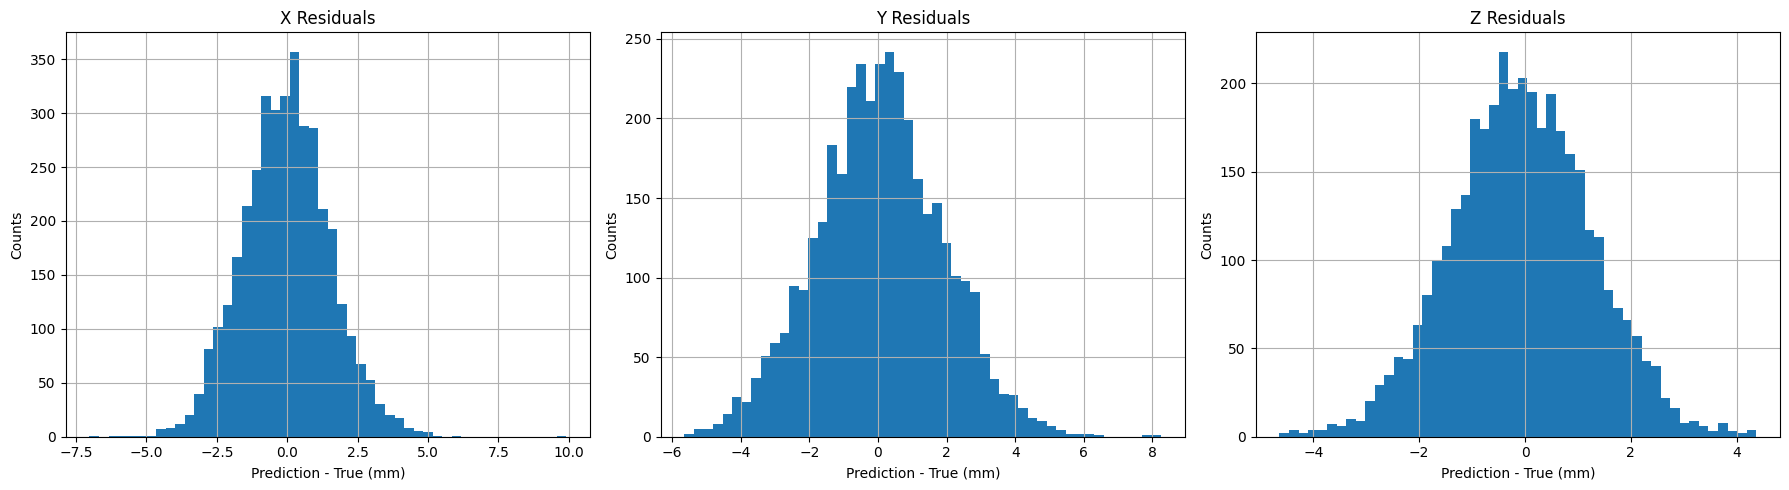

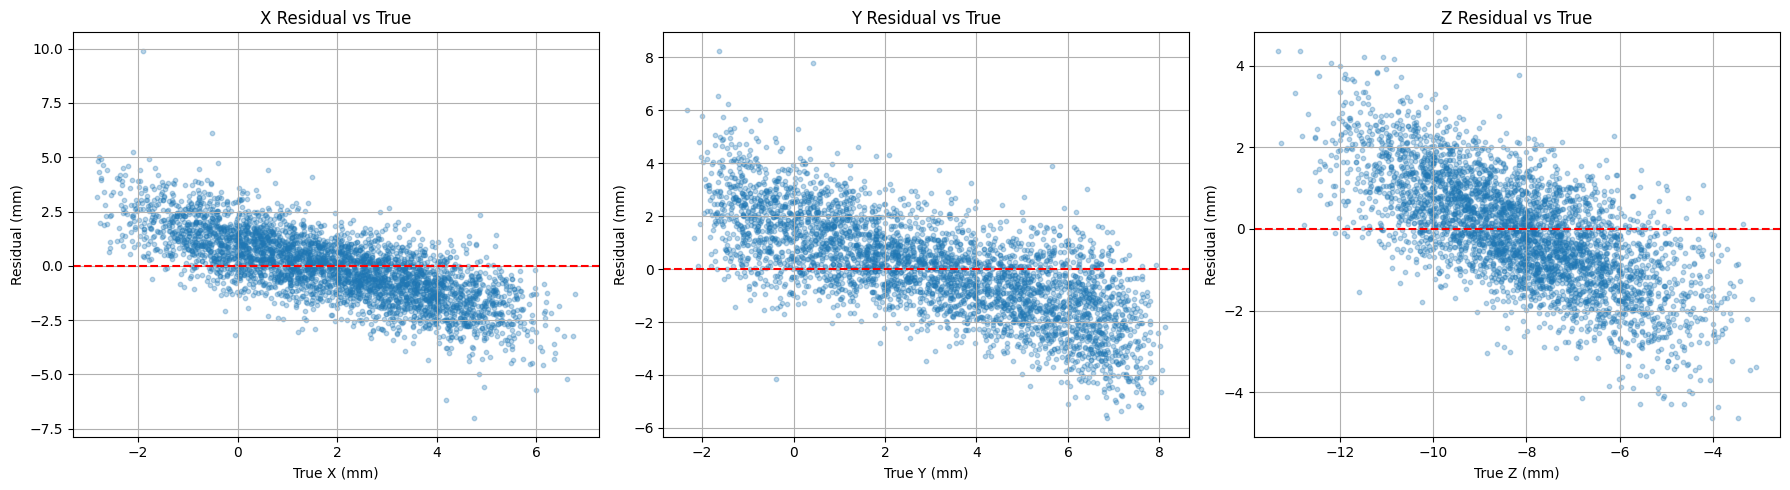

X
  Mean residual: -0.03 mm
  Std residual : 1.56 mm
  MAE          : 1.23 mm

Y
  Mean residual: 0.05 mm
  Std residual : 1.85 mm
  MAE          : 1.47 mm

Z
  Mean residual: -0.06 mm
  Std residual : 1.33 mm
  MAE          : 1.06 mm



In [23]:
residuals_A = prediction_A - y_test_A

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.hist(residuals_A[:, i], bins=50)
    ax.set_title(f"{coords[i]} Residuals")
    ax.set_xlabel("Prediction - True (mm)")
    ax.set_ylabel("Counts")
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.scatter(y_test_A[:, i], residuals_A[:, i], alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel("Residual (mm)")
    ax.set_title(f"{coords[i]} Residual vs True")
    ax.grid(True)
plt.tight_layout()
plt.show()

for i, coord in enumerate(coords):
    print(coord)
    print(f"  Mean residual: {np.mean(residuals_A[:, i]):.2f} mm")
    print(f"  Std residual : {np.std(residuals_A[:, i]):.2f} mm")
    print(f"  MAE          : {np.mean(np.abs(residuals_A[:, i])):.2f} mm")
    print()

### A.10 Summary

In [24]:
results_A = {
    "model": "Model A (Deterministic CNN)",
    "mae_x": mean_absolute_error(y_test_A[:, 0], prediction_A[:, 0]),
    "mae_y": mean_absolute_error(y_test_A[:, 1], prediction_A[:, 1]),
    "mae_z": mean_absolute_error(y_test_A[:, 2], prediction_A[:, 2]),
    "mae_overall": cnn_mae_A,
    "mean_3d_error_mm": np.mean(distance_error_A),
    "median_3d_error_mm": np.median(distance_error_A),
    "r2_overall": r2_overall_A,
}

results_A

{'model': 'Model A (Deterministic CNN)',
 'mae_x': 1.2289804220199585,
 'mae_y': 1.4652334451675415,
 'mae_z': 1.0580034255981445,
 'mae_overall': 1.2507377862930298,
 'mean_3d_error_mm': np.float32(2.5021005),
 'median_3d_error_mm': np.float32(2.3381288),
 'r2_overall': 0.4563628137111664}

**What changed vs. the original `CNNModel3GAMMA.ipynb`:**
- Removed the abandoned `Sequential` model definition (cell 26 in the original) — only the functional-API model that was actually trained is kept.
- Removed the stray `model.fit(X_train, ...)` cell that referenced an undefined `X_train` and duplicated the real training cell.
- Removed `accuracy` from `model.compile(...)`, and removed the accuracy plot and the accuracy line from `model.evaluate(...)` — accuracy isn't a meaningful metric for a continuous regression target.
- Removed duplicate "print shapes" cells and a duplicate `model.predict(...)` cell.
- Data loading and image-building code moved into the shared helper functions in Part 0.

---
## Part B — Probabilistic CNN (mean + uncertainty, with plane projection)

This model shares the same backbone as Model A, but the final layer outputs **six** numbers per event: a predicted mean position `(mu_x, mu_y, mu_z)` and a raw per-axis uncertainty `(sigma_x, sigma_y, sigma_z)`. It's trained with a Gaussian negative-log-likelihood (NLL) loss instead of MSE, so the network is rewarded for being both accurate *and* well-calibrated about its own uncertainty. Predictions are also refined by projecting them onto the plane defined by the three detector hits.

### B.1 Load data

In [25]:
ROOT_FILE_B = "augmerged.root"

df_B = load_three_gamma_events(ROOT_FILE_B)

print(df_B.head())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_36283167_1       43           0  22.533781  45.725643  -6.039716   
1  slurm_36283167_1       43           1 -19.154974 -41.295967  42.954437   
2  slurm_36283167_1       43           2  10.009033  22.802109 -44.240387   
3  slurm_36283167_1       56           0  15.187184  14.526692  46.622974   
4  slurm_36283167_1       56           1   1.183054 -10.753192 -51.622868   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         187.380234     187.380234             0.0     3.079860     6.565360   
1         471.598907     471.598907             0.0     3.079860     6.565360   
2         363.018677     363.018677             0.0     3.079860     6.565360   
3         492.708618     492.708618             0.0    -0.369778     0.324251   
4         304.623718     304.623718             0.0    -0.369778     0.324251   

   AnnihilZ_mm  
0    -6.969770  
1    -6.969770  

### B.2 Build detector images and regression targets

In [26]:
xmin_B, xmax_B, ymin_B, ymax_B, zmin_B, zmax_B = get_axis_ranges(df_B)
print(xmin_B, xmax_B)
print(ymin_B, ymax_B)
print(zmin_B, zmax_B)

images_B, targets_B, plane_features_B = build_images_targets_planes(
    df_B, xmin_B, xmax_B, ymin_B, ymax_B, zmin_B, zmax_B, img_size=IMG_SIZE
)

-99.15685272216797 95.1434555053711
-92.13552856445312 96.26758575439453
-95.55072784423828 98.47635650634766
Building images from 18591 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed

Images shape : (18591, 64, 64, 3)
Targets shape: (18591, 3)
Plane features shape: (18591, 4)


In [27]:
images_B = images_B / np.max(images_B)

print(images_B.min(), images_B.max())

0.0 1.0


### B.3 Train / validation / test split

This model uses a three-way split (train / val / test) so early stopping and hyperparameter choices can be checked on a held-out validation set, separate from the final test set.

In [28]:
x_train_B, x_temp_B, y_train_B, y_temp_B, plane_train_B, plane_temp_B = train_test_split(
    images_B,
    targets_B,
    plane_features_B,
    test_size=0.3,
    random_state=42,
    shuffle=True,
)

x_val_B, x_test_B, y_val_B, y_test_B, plane_val_B, plane_test_B = train_test_split(
    x_temp_B,
    y_temp_B,
    plane_temp_B,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

print("Train:", x_train_B.shape, y_train_B.shape, plane_train_B.shape)
print("Val:  ", x_val_B.shape, y_val_B.shape, plane_val_B.shape)
print("Test: ", x_test_B.shape, y_test_B.shape, plane_test_B.shape)

Train: (13013, 64, 64, 3) (13013, 3) (13013, 4)
Val:   (2789, 64, 64, 3) (2789, 3) (2789, 4)
Test:  (2789, 64, 64, 3) (2789, 3) (2789, 4)


### B.4 Scale targets

In [29]:
target_scaler_B = StandardScaler()

y_train_scaled_B = target_scaler_B.fit_transform(y_train_B)
y_val_scaled_B = target_scaler_B.transform(y_val_B)
y_test_scaled_B = target_scaler_B.transform(y_test_B)

print(y_train_scaled_B[0])

[-0.18592414  1.2884794  -0.5519326 ]


### B.5 Build the probabilistic model

In [30]:
image_input_B = Input(shape=(64, 64, 3), name="detector_image")
x_B = build_cnn_backbone(image_input_B)

plane_input_B = Input(shape=(4,), name="plane_equation")
plane_branch_B = build_plane_branch(plane_input_B)

combined_B = Concatenate()([x_B, plane_branch_B])
combined_B = Dense(128, activation="relu")(combined_B)
combined_B = Dropout(0.3)(combined_B)

# Probabilistic output: [mu_x, mu_y, mu_z, raw_sigma_x, raw_sigma_y, raw_sigma_z]
output_B = Dense(6, name="mu_and_raw_sigma")(combined_B)

model_B = Model(inputs=[image_input_B, plane_input_B], outputs=output_B)
model_B.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ detector_image      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 62, 62,    │        448 │ detector_image[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 31, 31,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 29, 29,    │      4,640 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 14, 14,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 12, 12,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 6, 6, 64)  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane_equation      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │         80 │ plane_equation[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2320)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │    297,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mu_and_raw_sigma    │ (None, 6)         │        774 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,526 (1.23 MB)

 Trainable params: 321,526 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### B.6 Gaussian negative log-likelihood loss

In [31]:
def gaussian_nll(y_true, y_pred):
    """Negative log-likelihood of the true position under a diagonal
    Gaussian with mean `mu` and standard deviation `sigma`, both predicted
    by the network (in scaled target units)."""

    mu = y_pred[:, :3]
    raw_sigma = y_pred[:, 3:]

    # softplus keeps sigma positive and numerically stable
    sigma = tf.nn.softplus(raw_sigma) + 1e-6

    nll = 0.5 * tf.square((y_true - mu) / sigma) + tf.math.log(sigma)

    return tf.reduce_mean(nll)

> **Note:** the original notebook also sketched a `gaussian_nll_with_plane` loss that added a penalty for predictions falling off the detector-hit plane. That version needed the plane coefficients inside the loss function itself, which isn't compatible with a standard Keras `(y_true, y_pred)` loss without a custom training loop — and it was never actually wired into `model.compile(...)`. Rather than leave dead code in place, the plane constraint is instead applied as a clean post-hoc projection step in **B.9**, which achieves the same physical goal.

### B.7 Compile & train

In [32]:
model_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=gaussian_nll,
)

history_B = model_B.fit(
    [x_train_B, plane_train_B],
    y_train_scaled_B,
    validation_data=([x_val_B, plane_val_B], y_val_scaled_B),
    epochs=50,
    batch_size=32,
)

Epoch 1/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 0.5087 - val_loss: 0.4673
Epoch 2/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4644 - val_loss: 0.4452
Epoch 3/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.4354 - val_loss: 0.4148
Epoch 4/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4017 - val_loss: 0.3887
Epoch 5/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3772 - val_loss: 0.3647
Epoch 6/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3544 - val_loss: 0.3383
Epoch 7/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3368 - val_loss: 0.3237
Epoch 8/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3226 - val_loss: 0.3149
Epoch 9/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3074 - val_loss: 0.3037
Epoch 10/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2928 - val_loss: 0.2863
Epoch 11/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2800 - val_loss: 0.2806
Epoch 12/50
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/st

### B.8 Training curve

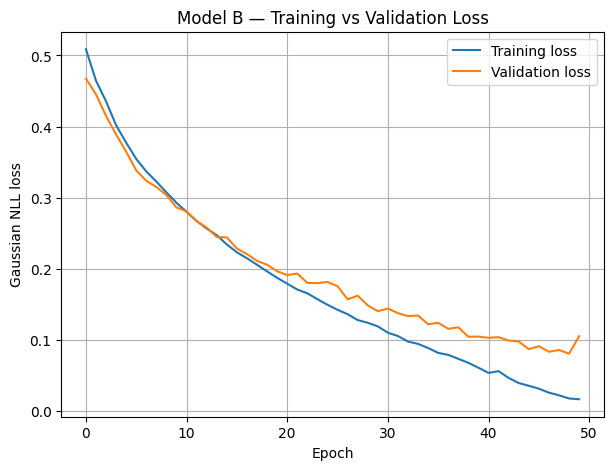

In [33]:
plt.figure(figsize=(7, 5))
plt.plot(history_B.history["loss"], label="Training loss")
plt.plot(history_B.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Gaussian NLL loss")
plt.title("Model B — Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

### B.9 Predictions: mean, uncertainty, and plane projection

In [34]:
raw_prediction_B = model_B.predict([x_test_B, plane_test_B])

mu_scaled_B = raw_prediction_B[:, :3]
sigma_scaled_B = tf.nn.softplus(raw_prediction_B[:, 3:]).numpy() + 1e-6

# Undo target scaling: for a StandardScaler, std_original = std_scaled * scale_
mu_mm_B = target_scaler_B.inverse_transform(mu_scaled_B)
sigma_mm_B = sigma_scaled_B * target_scaler_B.scale_

print("mu_mm shape:", mu_mm_B.shape)
print("sigma_mm shape:", sigma_mm_B.shape)

for i in range(5):
    print("Event", i)
    print("  True:       ", y_test_B[i])
    print("  Predicted:  ", mu_mm_B[i])
    print("  Uncertainty:", sigma_mm_B[i])
    print()

88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
mu_mm shape: (2789, 3)
sigma_mm shape: (2789, 3)
Event 0
  True:        [  4.9761834   0.3410897 -10.657421 ]
  Predicted:   [ 2.3788986  2.8540335 -8.656295 ]
  Uncertainty: [1.17722804 1.49607649 1.21443704]

Event 1
  True:        [ 4.6802645  5.131514  -9.532785 ]
  Predicted:   [  3.4183047   2.589133  -10.694417 ]
  Uncertainty: [1.34164124 2.0859371  1.21564219]

Event 2
  True:        [ 0.9647649  2.1288269 -6.3443527]
  Predicted:   [ 0.5294367  1.1267473 -7.7603745]
  Uncertainty: [1.00603417 1.76280521 1.25176564]

Event 3
  True:        [ 1.3216504  6.7202992 -4.0047636]
  Predicted:   [ 1.4685504  6.5805182 -5.5933013]
  Uncertainty: [1.36958158 1.22035365 1.10117874]

Event 4
  True:        [ 2.5921383  2.2871537 -8.874028 ]
  Predicted:   [ 2.938978   2.4686816 -8.781076 ]
  Uncertainty: [1.19943164 2.05406296 1.11407138]



In [35]:
# Project the predicted mean onto the plane defined by the 3 detector hits
normal_B = plane_test_B[:, :3]
D_B = plane_test_B[:, 3]

signed_distance_B = np.sum(normal_B * mu_mm_B, axis=1) + D_B
mu_mm_B_projected = mu_mm_B - signed_distance_B[:, None] * normal_B

mae_original_B = mean_absolute_error(y_test_B, mu_mm_B)
mae_projected_B = mean_absolute_error(y_test_B, mu_mm_B_projected)

print("MAE before projection:", mae_original_B, "mm")
print("MAE after projection: ", mae_projected_B, "mm")

MAE before projection: 1.1984065771102905 mm
MAE after projection:  1.1045327186584473 mm


In [36]:
original_error_B = mu_mm_B - y_test_B
projected_error_B = mu_mm_B_projected - y_test_B

original_distance_B = np.sqrt(np.sum(original_error_B ** 2, axis=1))
projected_distance_B = np.sqrt(np.sum(projected_error_B ** 2, axis=1))

print("Mean 3D error before projection:  ", np.mean(original_distance_B), "mm")
print("Mean 3D error after projection:   ", np.mean(projected_distance_B), "mm")
print("Median 3D error before projection:", np.median(original_distance_B), "mm")
print("Median 3D error after projection: ", np.median(projected_distance_B), "mm")

Mean 3D error before projection:   2.4067757 mm
Mean 3D error after projection:    2.2173522 mm
Median 3D error before projection: 2.2491562 mm
Median 3D error after projection:  2.070005 mm


### B.10 Visual checks

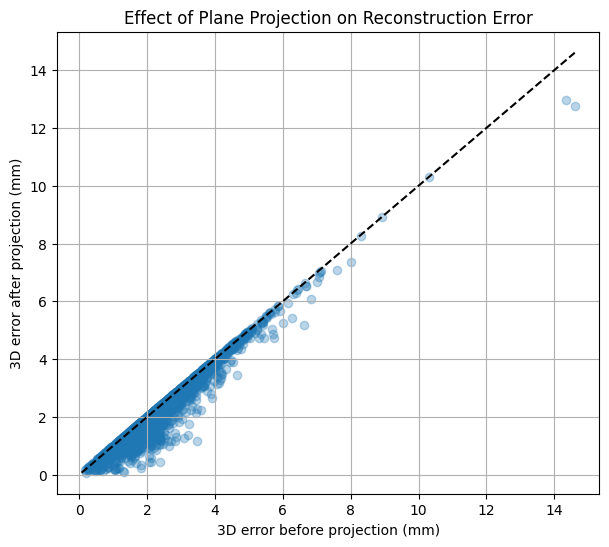

In [37]:
plt.figure(figsize=(7, 6))
plt.scatter(original_distance_B, projected_distance_B, alpha=0.3)

lo = min(original_distance_B.min(), projected_distance_B.min())
hi = max(original_distance_B.max(), projected_distance_B.max())
plt.plot([lo, hi], [lo, hi], color="black", linestyle="--")

plt.xlabel("3D error before projection (mm)")
plt.ylabel("3D error after projection (mm)")
plt.title("Effect of Plane Projection on Reconstruction Error")
plt.grid()
plt.show()

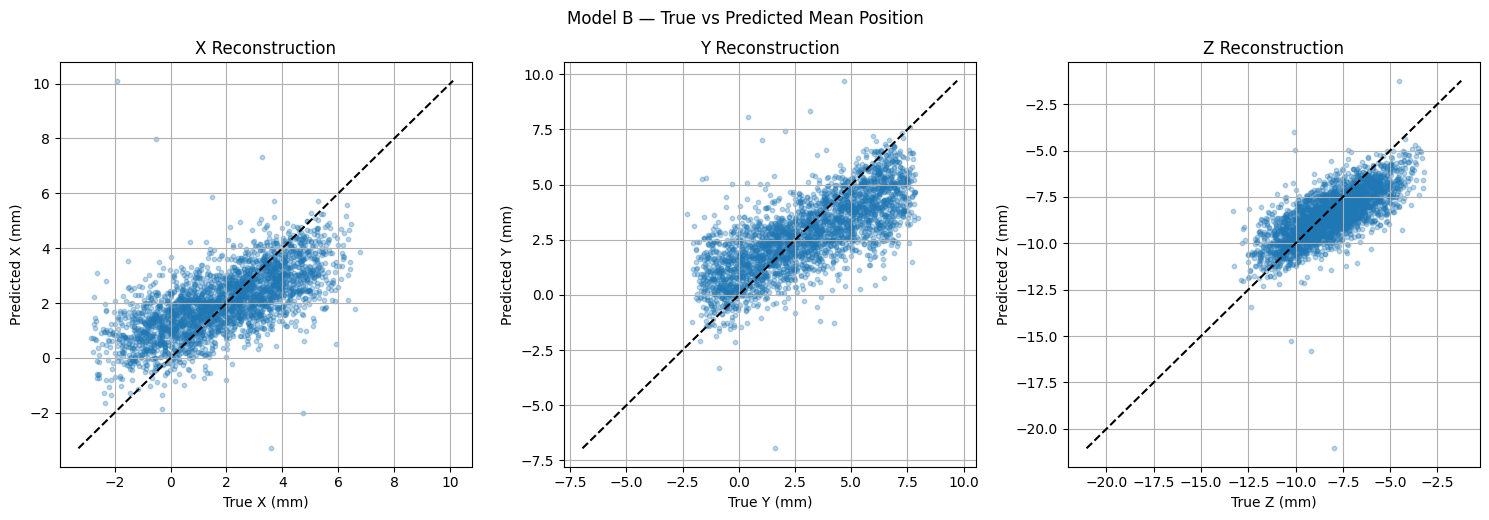

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
coords = ["X", "Y", "Z"]

for i, ax in enumerate(axes):
    ax.scatter(y_test_B[:, i], mu_mm_B[:, i], alpha=0.3, s=10)
    lo = min(y_test_B[:, i].min(), mu_mm_B[:, i].min())
    hi = max(y_test_B[:, i].max(), mu_mm_B[:, i].max())
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"Predicted {coords[i]} (mm)")
    ax.set_title(f"{coords[i]} Reconstruction")
    ax.grid(True)

plt.tight_layout()
plt.suptitle("Model B — True vs Predicted Mean Position", y=1.03)
plt.show()

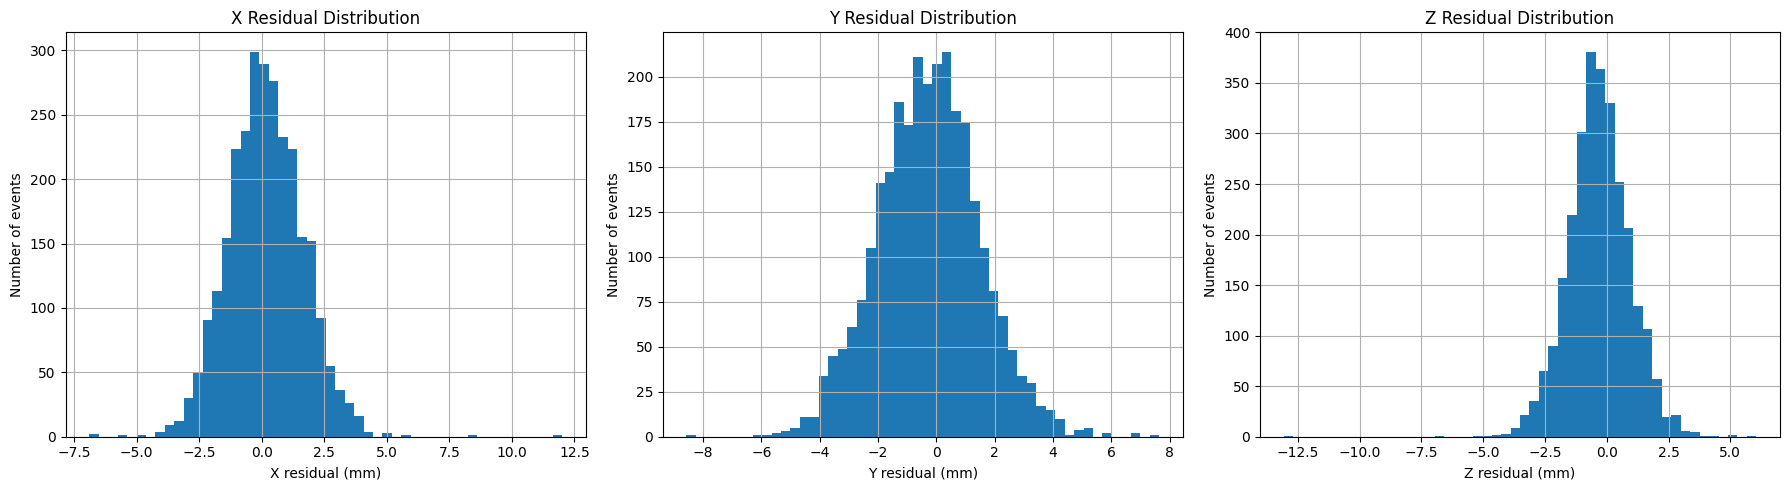

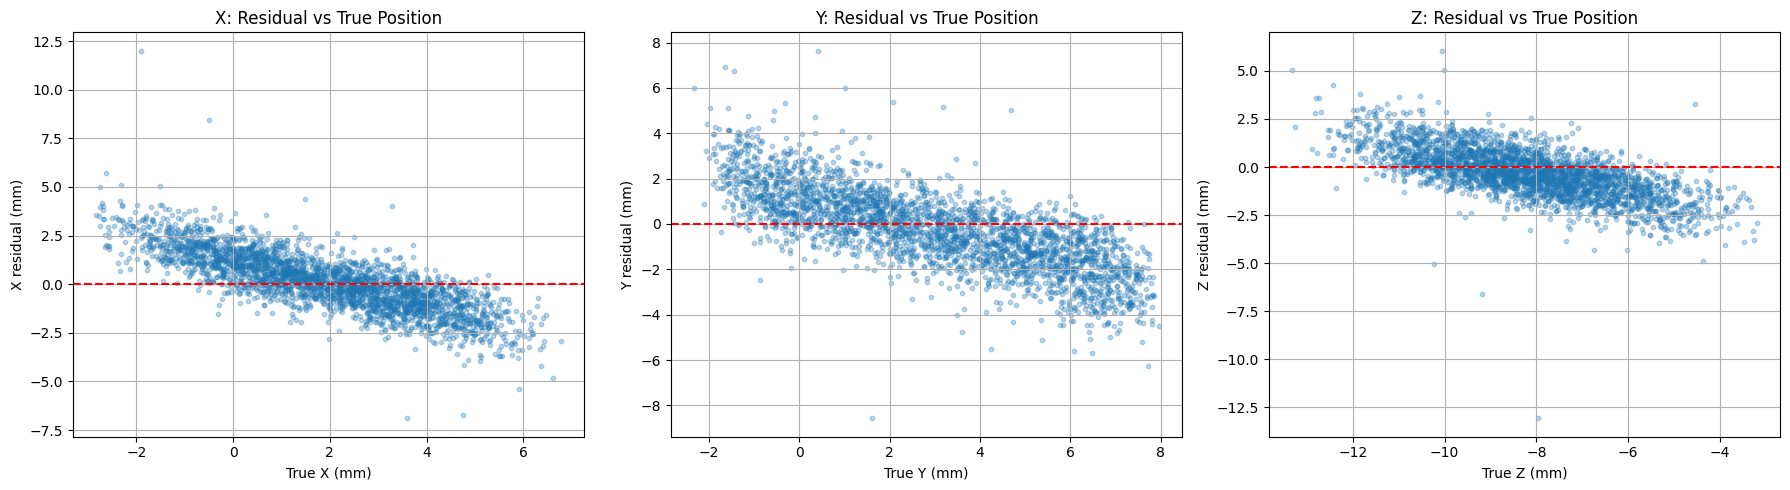

In [39]:
residuals_B = mu_mm_B - y_test_B

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.hist(residuals_B[:, i], bins=50)
    ax.set_xlabel(f"{coords[i]} residual (mm)")
    ax.set_ylabel("Number of events")
    ax.set_title(f"{coords[i]} Residual Distribution")
    ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    ax.scatter(y_test_B[:, i], residuals_B[:, i], alpha=0.3, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel(f"True {coords[i]} (mm)")
    ax.set_ylabel(f"{coords[i]} residual (mm)")
    ax.set_title(f"{coords[i]}: Residual vs True Position")
    ax.grid(True)
plt.tight_layout()
plt.show()

### B.11 Uncertainty analysis

Uncertainty-error correlation: 0.28001656527393737


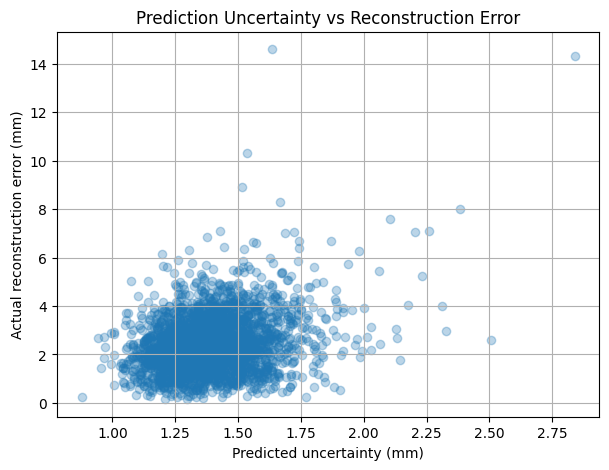

In [40]:
mean_sigma_B = np.mean(sigma_mm_B, axis=1)

correlation_B = np.corrcoef(mean_sigma_B, original_distance_B)[0, 1]
print("Uncertainty-error correlation:", correlation_B)

plt.figure(figsize=(7, 5))
plt.scatter(mean_sigma_B, original_distance_B, alpha=0.3)
plt.xlabel("Predicted uncertainty (mm)")
plt.ylabel("Actual reconstruction error (mm)")
plt.title("Prediction Uncertainty vs Reconstruction Error")
plt.grid()
plt.show()

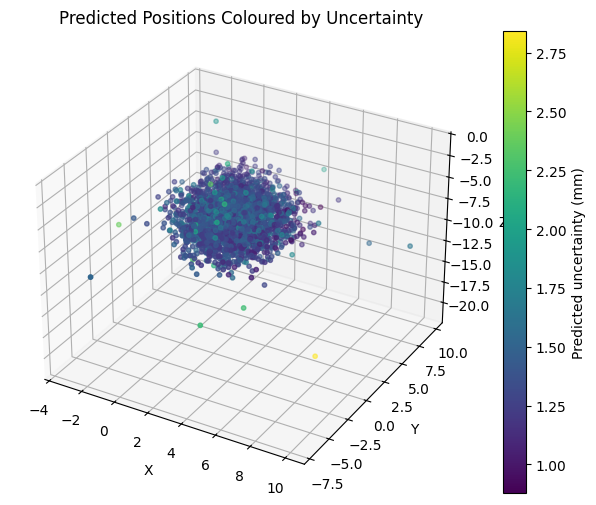

In [41]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(mu_mm_B[:, 0], mu_mm_B[:, 1], mu_mm_B[:, 2], c=mean_sigma_B, s=10)
plt.colorbar(sc, label="Predicted uncertainty (mm)")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Predicted Positions Coloured by Uncertainty")
plt.show()

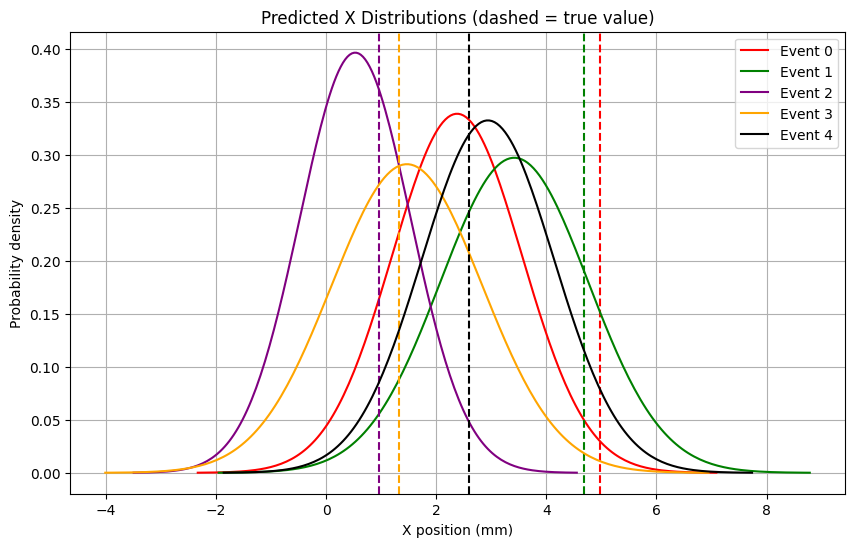

In [42]:
plt.figure(figsize=(10, 6))

events = [0, 1, 2, 3, 4]
colours = ["red", "green", "purple", "orange", "black"]

for event, colour in zip(events, colours):
    x = np.linspace(
        mu_mm_B[event, 0] - 4 * sigma_mm_B[event, 0],
        mu_mm_B[event, 0] + 4 * sigma_mm_B[event, 0],
        200,
    )
    pdf = (
        1 / (sigma_mm_B[event, 0] * np.sqrt(2 * np.pi))
        * np.exp(-(x - mu_mm_B[event, 0]) ** 2 / (2 * sigma_mm_B[event, 0] ** 2))
    )
    plt.plot(x, pdf, color=colour, label=f"Event {event}")
    plt.axvline(y_test_B[event, 0], color=colour, linestyle="--")

plt.xlabel("X position (mm)")
plt.ylabel("Probability density")
plt.title("Predicted X Distributions (dashed = true value)")
plt.legend()
plt.grid()
plt.show()

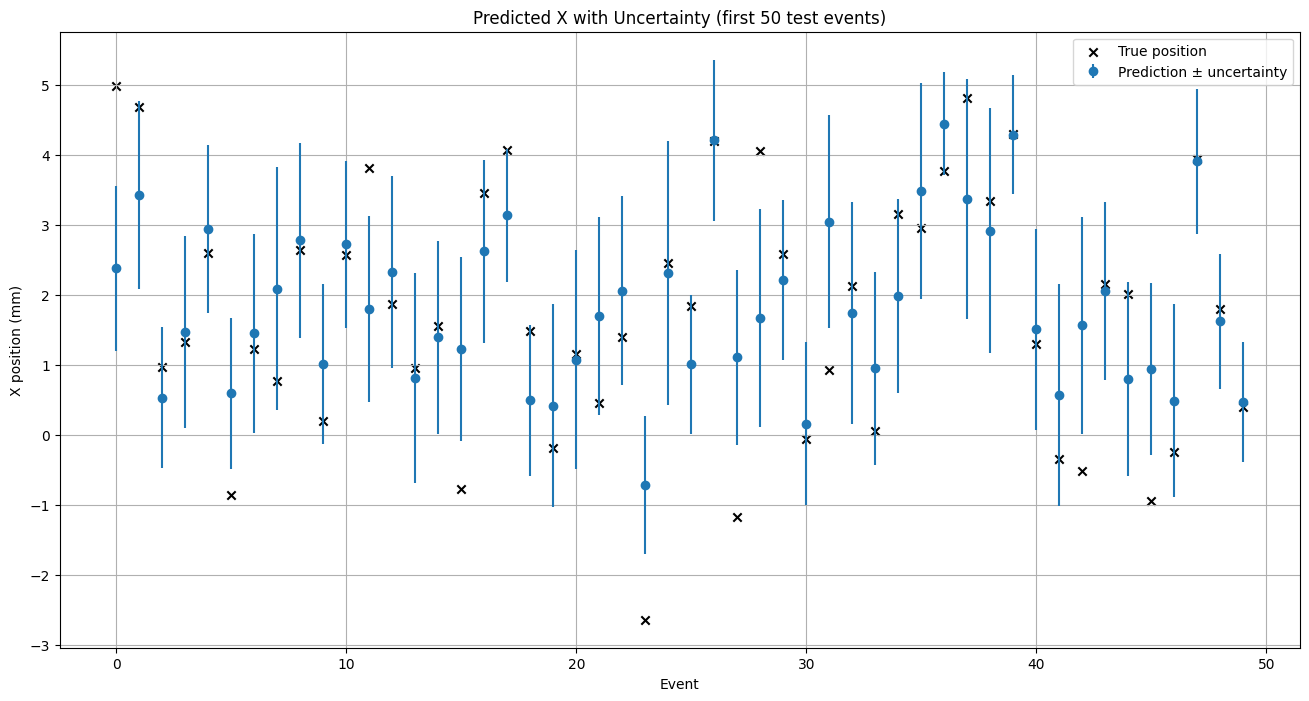

In [43]:
idx = np.arange(50)

plt.figure(figsize=(16, 8))
plt.errorbar(idx, mu_mm_B[:50, 0], yerr=sigma_mm_B[:50, 0], fmt="o", label="Prediction ± uncertainty")
plt.scatter(idx, y_test_B[:50, 0], marker="x", color="black", label="True position")

plt.xlabel("Event")
plt.ylabel("X position (mm)")
plt.title("Predicted X with Uncertainty (first 50 test events)")
plt.legend()
plt.grid()
plt.show()

### B.12 Summary

In [44]:
r2_overall_B = r2_score(y_test_B, mu_mm_B_projected)

results_B = {
    "model": "Model B (Probabilistic CNN, plane-projected)",
    "mae_x": mean_absolute_error(y_test_B[:, 0], mu_mm_B_projected[:, 0]),
    "mae_y": mean_absolute_error(y_test_B[:, 1], mu_mm_B_projected[:, 1]),
    "mae_z": mean_absolute_error(y_test_B[:, 2], mu_mm_B_projected[:, 2]),
    "mae_overall": mae_projected_B,
    "mean_3d_error_mm": np.mean(projected_distance_B),
    "median_3d_error_mm": np.median(projected_distance_B),
    "r2_overall": r2_overall_B,
    "mean_uncertainty_mm": np.mean(mean_sigma_B),
    "uncertainty_error_correlation": correlation_B,
}

results_B

{'model': 'Model B (Probabilistic CNN, plane-projected)',
 'mae_x': 1.0887095928192139,
 'mae_y': 1.2419756650924683,
 'mae_z': 0.9829121828079224,
 'mae_overall': 1.1045327186584473,
 'mean_3d_error_mm': np.float32(2.2173522),
 'median_3d_error_mm': np.float32(2.070005),
 'r2_overall': 0.5417945981025696,
 'mean_uncertainty_mm': np.float64(1.387139230040168),
 'uncertainty_error_correlation': np.float64(0.28001656527393737)}

**What changed vs. the original `probablisticCNN.ipynb`:**
- The model's output layer now actually produces `mu` and `sigma` (`Dense(6)`), and is compiled with `gaussian_nll` as its loss. In the original notebook the model was compiled with plain `"mse"` and a `Dense(3)` output, while later cells referenced `mu_mm` / `sigma_mm` that were never defined anywhere — so the uncertainty analysis further down couldn't actually have run. This version wires the probabilistic head up properly so the notebook's own title ("predicting annihilation *probability* over position") is actually implemented.
- Fixed a variable-name collision: the original notebook used `plane_features` for both the training-data array and the Dense layer output inside the model, silently overwriting the data. These are now `plane_features_B` (data) and `plane_branch_B` (layer) respectively.
- Removed the duplicate `model.fit(...)` cell that trained on unscaled targets — training now happens once, on the scaled targets.
- Removed the duplicate `StandardScaler` cell and the duplicate uncertainty-correlation cell.
- Removed the "IGNORE" cells and dead `gaussian_nll_with_plane` function (see the note in B.6 above for why).

---
## Part C — Comparing Model A and Model B

A quick caveat first: **Model A was trained on `new3merged.root` and Model B was trained on `augmerged.root`** — two different datasets. So this isn't a strictly controlled head-to-head; it's a comparison of how each *pipeline* performs on its own held-out test set. If you want a true apples-to-apples comparison, re-run both models on the same ROOT file.

With that in mind, here's how the two approaches compare.

In [45]:
comparison_rows = [
    {
        "Model": "A: Deterministic CNN",
        "MAE X (mm)": results_A["mae_x"],
        "MAE Y (mm)": results_A["mae_y"],
        "MAE Z (mm)": results_A["mae_z"],
        "Overall MAE (mm)": results_A["mae_overall"],
        "Mean 3D error (mm)": results_A["mean_3d_error_mm"],
        "Median 3D error (mm)": results_A["median_3d_error_mm"],
        "R2": results_A["r2_overall"],
    },
    {
        "Model": "B: Probabilistic CNN (plane-projected)",
        "MAE X (mm)": results_B["mae_x"],
        "MAE Y (mm)": results_B["mae_y"],
        "MAE Z (mm)": results_B["mae_z"],
        "Overall MAE (mm)": results_B["mae_overall"],
        "Mean 3D error (mm)": results_B["mean_3d_error_mm"],
        "Median 3D error (mm)": results_B["median_3d_error_mm"],
        "R2": results_B["r2_overall"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
comparison_df

,MAE X (mm),MAE Y (mm),MAE Z (mm),Overall MAE (mm),Mean 3D error (mm),Median 3D error (mm),R2
Model,,,,,,,
A: Deterministic CNN,1.22898,1.465233,1.058003,1.250738,2.502100,2.338129,0.456363
B: Probabilistic CNN (plane-projected),1.08871,1.241976,0.982912,1.104533,2.217352,2.070005,0.541795


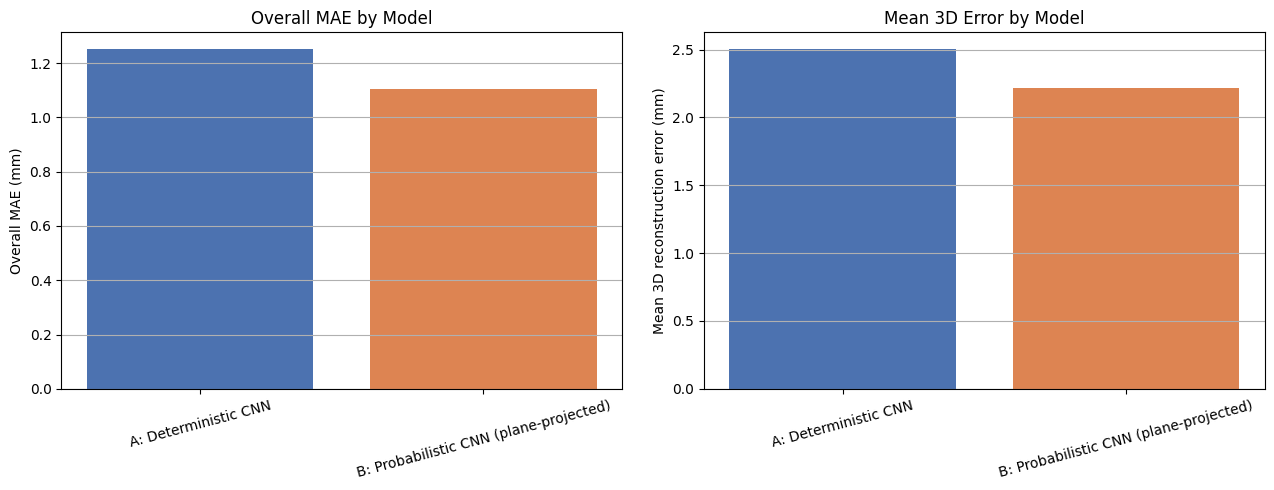

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models = comparison_df.index.tolist()

axes[0].bar(models, comparison_df["Overall MAE (mm)"], color=["#4C72B0", "#DD8452"])
axes[0].set_ylabel("Overall MAE (mm)")
axes[0].set_title("Overall MAE by Model")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y")

axes[1].bar(models, comparison_df["Mean 3D error (mm)"], color=["#4C72B0", "#DD8452"])
axes[1].set_ylabel("Mean 3D reconstruction error (mm)")
axes[1].set_title("Mean 3D Error by Model")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

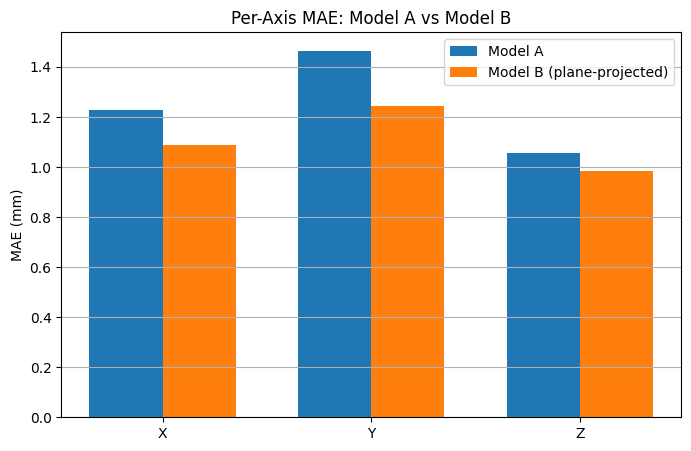

In [47]:
# Per-axis MAE side by side
axis_labels = ["X", "Y", "Z"]
mae_A_axes = [results_A["mae_x"], results_A["mae_y"], results_A["mae_z"]]
mae_B_axes = [results_B["mae_x"], results_B["mae_y"], results_B["mae_z"]]

x_pos = np.arange(len(axis_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width / 2, mae_A_axes, width, label="Model A")
plt.bar(x_pos + width / 2, mae_B_axes, width, label="Model B (plane-projected)")

plt.xticks(x_pos, axis_labels)
plt.ylabel("MAE (mm)")
plt.title("Per-Axis MAE: Model A vs Model B")
plt.legend()
plt.grid(axis="y")
plt.show()

### Reading the comparison

- **Accuracy metrics (MAE, 3D error, R²)** are directly comparable in kind between the two models, even though they come from different datasets — both describe how close the predicted annihilation position is to the truth, in millimetres.
- **Model B has one extra thing Model A doesn't**: a calibrated per-axis uncertainty (`sigma_mm_B`) alongside every prediction, plus a physically motivated refinement step (projecting onto the detector-hit plane). The `uncertainty_error_correlation` value in `results_B` tells you whether that uncertainty is actually informative — a positive correlation means the model tends to report higher uncertainty on events where it's genuinely less accurate, which is useful for flagging low-confidence reconstructions even without a ground-truth label.
- If Model B's plane-projected MAE is lower than Model A's, that's evidence the physics-informed projection step is pulling genuine value out of the detector geometry, on top of what the CNN learns from the image alone.
- To make this a fully controlled comparison, run both pipelines on the same ROOT file and consider also reporting Model A's error broken down the same way B's uncertainty is (e.g., MAE conditioned on some proxy for event difficulty), so the two are compared on equal footing.

### What was removed for general tidying

- All uses of the `accuracy` metric (in `model.compile(...)`, the training-curve plots, and `model.evaluate(...)`) — meaningless for a regression target, so it's gone from both models.
- Duplicate pip-install/import cells, duplicate scaler cells, duplicate `model.fit(...)` calls, and empty placeholder cells.
- Repeated event→image and CNN-backbone code, now shared via the helper functions in Part 0.
- Dead/never-wired-up code (the abandoned `Sequential` model in the original Model A notebook; the unused `gaussian_nll_with_plane` in the original Model B notebook).